# This notebook shows how to fit a Fano resonance in the reflection configuration.

A Fano resonance arises from interference between a resonant pathway (through the resonator) and a direct non-resonant pathway. The resulting lineshape is asymmetric and is parameterized by `fano_asymmetry` (q in the literature). When `fano_asymmetry = 0` the model reduces to a symmetric Lorentzian, identical to `LinearReflectionFitter`.

In [1]:
from __future__ import division, absolute_import, print_function
%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np

from resonator import background, see
from resonator.fano import FanoReflectionFitter

## Load data

Load measured S21 data (magnitude in dB and phase in degrees) from a CSV file. The data is converted to a complex scattering parameter. Uncomment the desired file and frequency window.

In [2]:
import pandas as pd
import numpy as np

# df = pd.read_csv("/Users/b3-34/Projects/uni/bakalaurinis/matavimai/droplet_csv/1.csv", skiprows=2)
df = pd.read_csv("/Users/b3-34/Projects/uni/bakalaurinis/matavimai/droplet_csv/2.csv", skiprows=2)
# df = pd.read_csv("/Users/b3-34/Projects/uni/bakalaurinis/matavimai/droplet_csv/3.csv", skiprows=2)
# df = pd.read_csv("/Users/b3-34/Projects/uni/bakalaurinis/matavimai/droplet_csv/4.csv", skiprows=2)
# df = pd.read_csv("/Users/b3-34/Projects/uni/bakalaurinis/matavimai/droplet_csv/5.csv", skiprows=2)
# df = pd.read_csv("/Users/b3-34/Projects/uni/bakalaurinis/matavimai/droplet_csv/6.csv", skiprows=2)

df.columns = ['frequency', 'S21_db', 'S21_deg']
df['S21'] = np.float_power(10, df['S21_db'].to_numpy()/20)

# Filter frequencies around mode

# freq_min = 10.02e9    # droplet 1
# freq_max = 10.07e9
freq_min = 9.2e9    # droplet 2
freq_max = 9.23e9
# freq_min = 9.465e9  # droplet 3
# freq_max = 9.525e9
# freq_min = 9.15e9   # droplet 4
# freq_max = 9.2e9
# freq_min = 9.19e9   # droplet 5
# freq_max = 9.225e9
# freq_min = 9.42e9   # droplet 6
# freq_max = 9.46e9

df = df[(df['frequency'] >= freq_min) & (df['frequency'] <= freq_max)]

data = df['S21'].to_numpy() * np.exp(1j * np.deg2rad(df["S21_deg"])).to_numpy()
frequency = df["frequency"].to_numpy()
print(df.head())

         frequency    S21_db    S21_deg       S21
2000  9.200025e+09 -5.097208  47.777685  0.556083
2001  9.200075e+09 -5.091913  47.579316  0.556422
2002  9.200125e+09 -5.090194  47.372822  0.556532
2003  9.200175e+09 -5.091963  47.160337  0.556419
2004  9.200225e+09 -5.094405  46.949871  0.556262


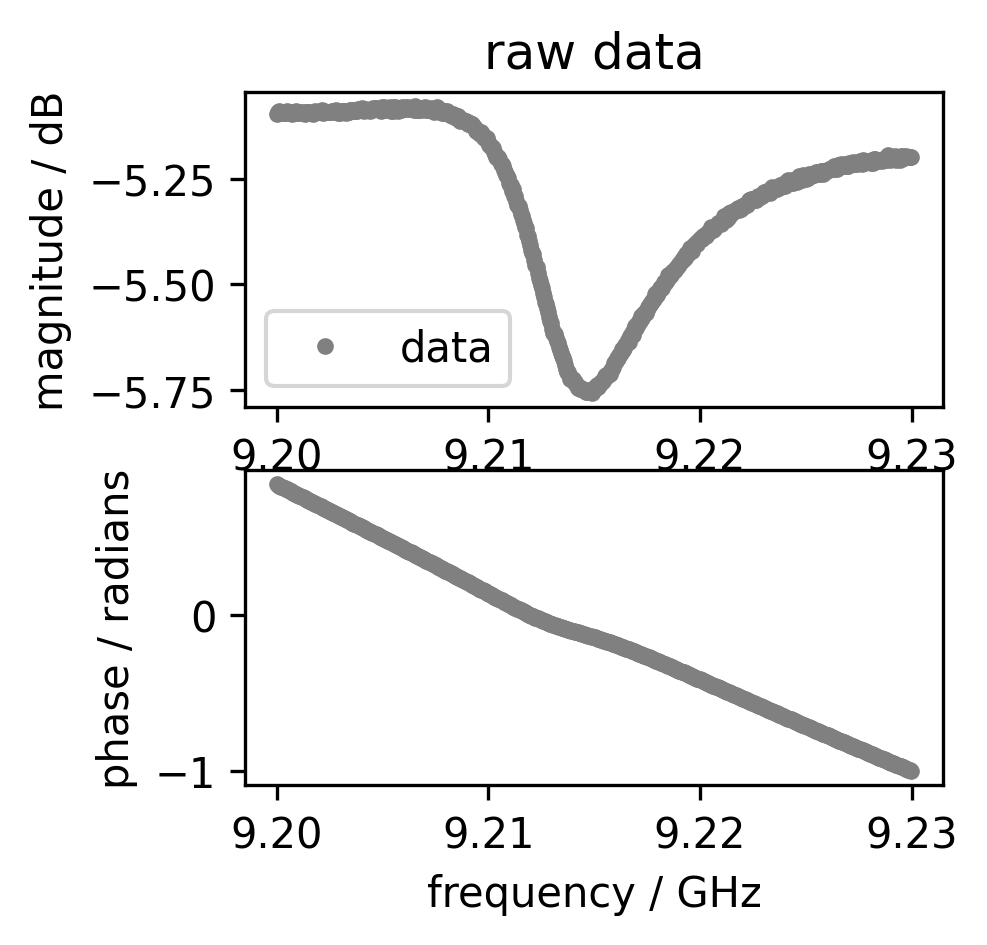

In [3]:
fig, (ax_mag, ax_phase) = plt.subplots(2, 1, figsize=(3, 3), dpi=300)

ax_mag.set_ylabel('magnitude / dB')
ax_mag.plot(1e-9 * frequency, 20 * np.log10(np.abs(data)), '.', color='gray', label='data')
ax_mag.set_title('raw data')
ax_mag.legend()

ax_phase.set_xlabel('frequency / GHz')
ax_phase.set_ylabel('phase / radians')
ax_phase.plot(1e-9 * frequency, np.angle(data), '.', color='gray', label='data')

## Fit the model to the data using a FanoReflectionFitter.

The `FanoReflectionFitter` fits the data to:

$$S_{11} = -1 + \frac{2(1 + j \cdot q)}{1 + (\kappa_i + 2j\delta)/\kappa_c}$$

where $\delta = f/f_r - 1$ is the fractional detuning, $\kappa_c$ is the coupling loss (= 1/Q_c), $\kappa_i$ is the internal loss (= 1/Q_i), and $q$ is the Fano asymmetry parameter.

The full model is the product of this foreground with a background model. Here we use `MagnitudePhaseDelay` which accounts for a constant magnitude offset, a phase offset, and a linear (cable delay) phase slope.

If no errors are given, the fitting assumes equal weights for each point.

In [4]:
import lmfit

params = lmfit.Parameters()
params.add(name='internal_loss', value=1e-9)
resonator = FanoReflectionFitter(frequency=frequency, data=data, params=params,
                                  background_model=background.MagnitudePhaseDelay())
print(resonator.result.fit_report())

[[Model]]
    (Model(magnitude_phase_delay) * Model(fano_reflection))
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 107
    # data points      = 1200
    # variables        = 7
    chi-square         = 0.03220028
    reduced chi-square = 2.6991e-05
    Akaike info crit   = -12617.0285
    Bayesian info crit = -12581.3980
    R-squared          = np.complex128(-5926086321845.03+701323351638.2535j)
[[Variables]]
    frequency_reference:  9.215004e+09 (fixed)
    magnitude:            0.55284951 +/- 3.8346e-04 (0.07%) (init = 0.5188149)
    phase:                3.03656761 +/- 5.5029e-04 (0.02%) (init = 2.99045)
    delay:               -9.8691e-09 +/- 1.0683e-11 (0.11%) (init = -8.784996e-09)
    resonance_frequency:  9.2132e+09 +/- 73714.6105 (0.00%) (init = 9.211653e+09)
    coupling_loss:        1.8735e-05 +/- 7.8349e-07 (4.18%) (init = 0.001391249)
    internal_loss:        6.8524e-04 +/- 1.6383e-05 (2.39%) (init = 1e-09)
    fano_asymmetry:       1.189

## Inspect fitted parameters

In [5]:
print(f"Resonance frequency:  {resonator.resonance_frequency * 1e-9:.6f} GHz  ±  {resonator.resonance_frequency_error * 1e-9:.3e} GHz")
print(f"Fano asymmetry (q):   {resonator.fano_asymmetry:.4f}  ±  {resonator.fano_asymmetry_error:.4f}")
print(f"Coupling loss (1/Qc): {resonator.coupling_loss:.4e}  ±  {resonator.coupling_loss_error:.4e}")
print(f"Internal loss (1/Qi): {resonator.internal_loss:.4e}  ±  {resonator.internal_loss_error:.4e}")
print()
print(f"Q_c = {resonator.Q_c:.0f}")
print(f"Q_i = {resonator.Q_i:.0f}")
print(f"Q_t = {resonator.Q_t:.0f}")

Resonance frequency:  9.213175 GHz  ±  7.371e-05 GHz
Fano asymmetry (q):   1.1897  ±  0.0541
Coupling loss (1/Qc): 1.8735e-05  ±  7.8349e-07
Internal loss (1/Qi): 6.8524e-04  ±  1.6383e-05

Q_c = 53375
Q_i = 1459
Q_t = 1420


## Plot the data

Use the `see.py` module to plot the data, model, and resonance. The normalized (resonator plane) data shows the Fano lineshape after removing the background. Note that unlike a symmetric resonance, the Fano lineshape does not trace a perfect circle centred on the off-resonance point in the complex plane.

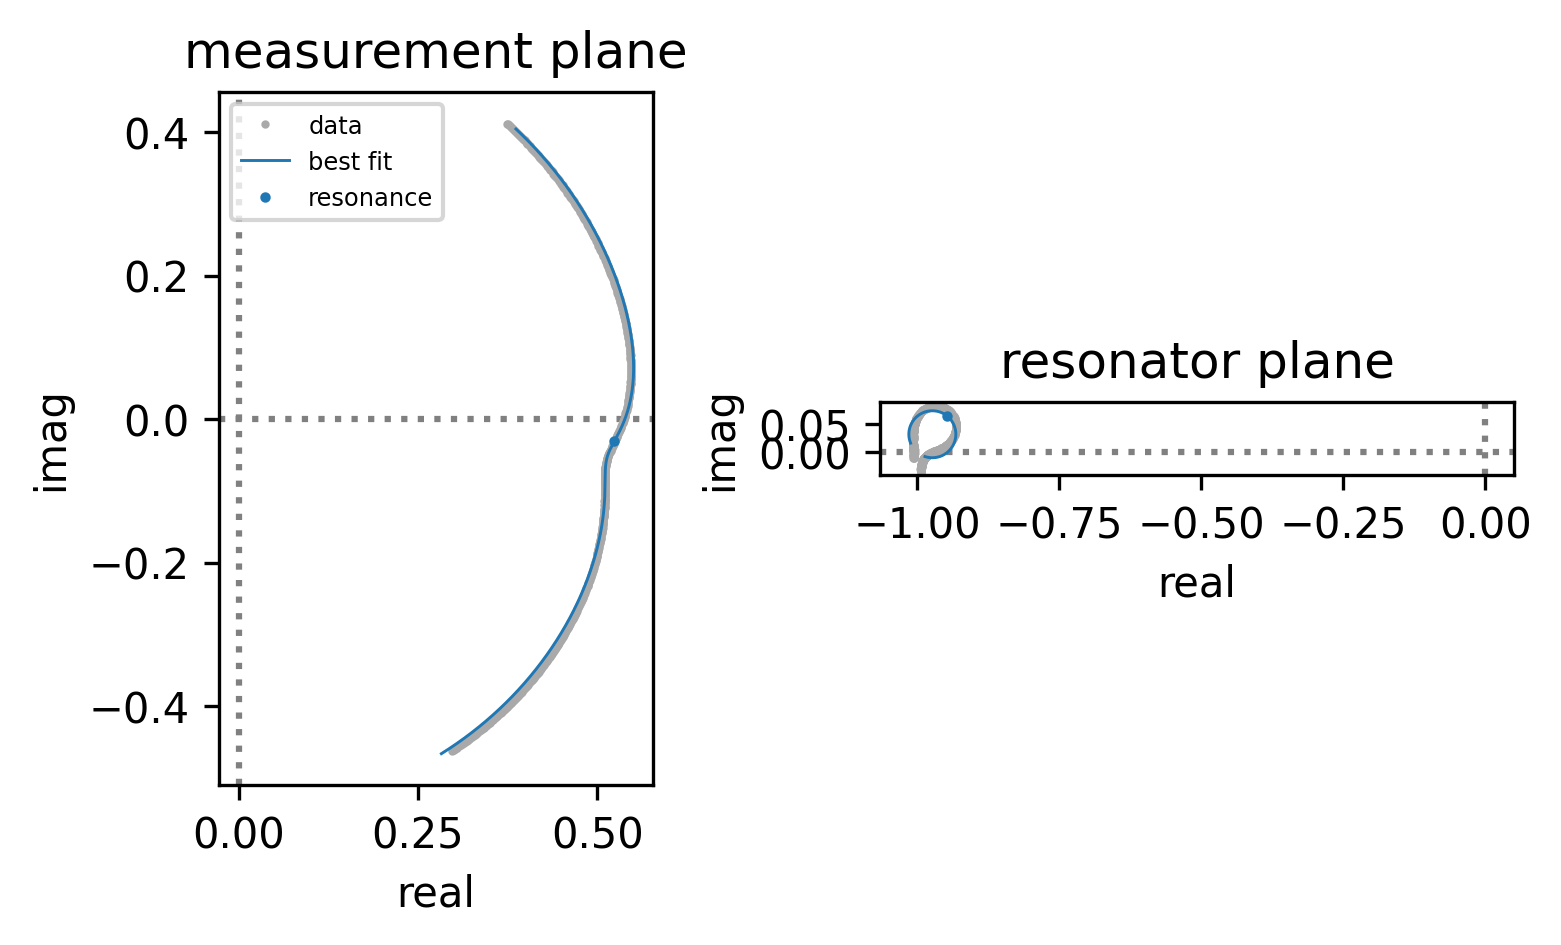

In [6]:
fig, (ax_raw, ax_norm) = plt.subplots(1, 2, figsize=(6, 3), dpi=300)
ax_raw.set_title('measurement plane')
ax_norm.set_title('resonator plane')
see.real_and_imaginary(resonator=resonator, axes=ax_raw, normalize=False)
see.real_and_imaginary(resonator=resonator, axes=ax_norm, normalize=True)
ax_raw.legend(fontsize='xx-small');

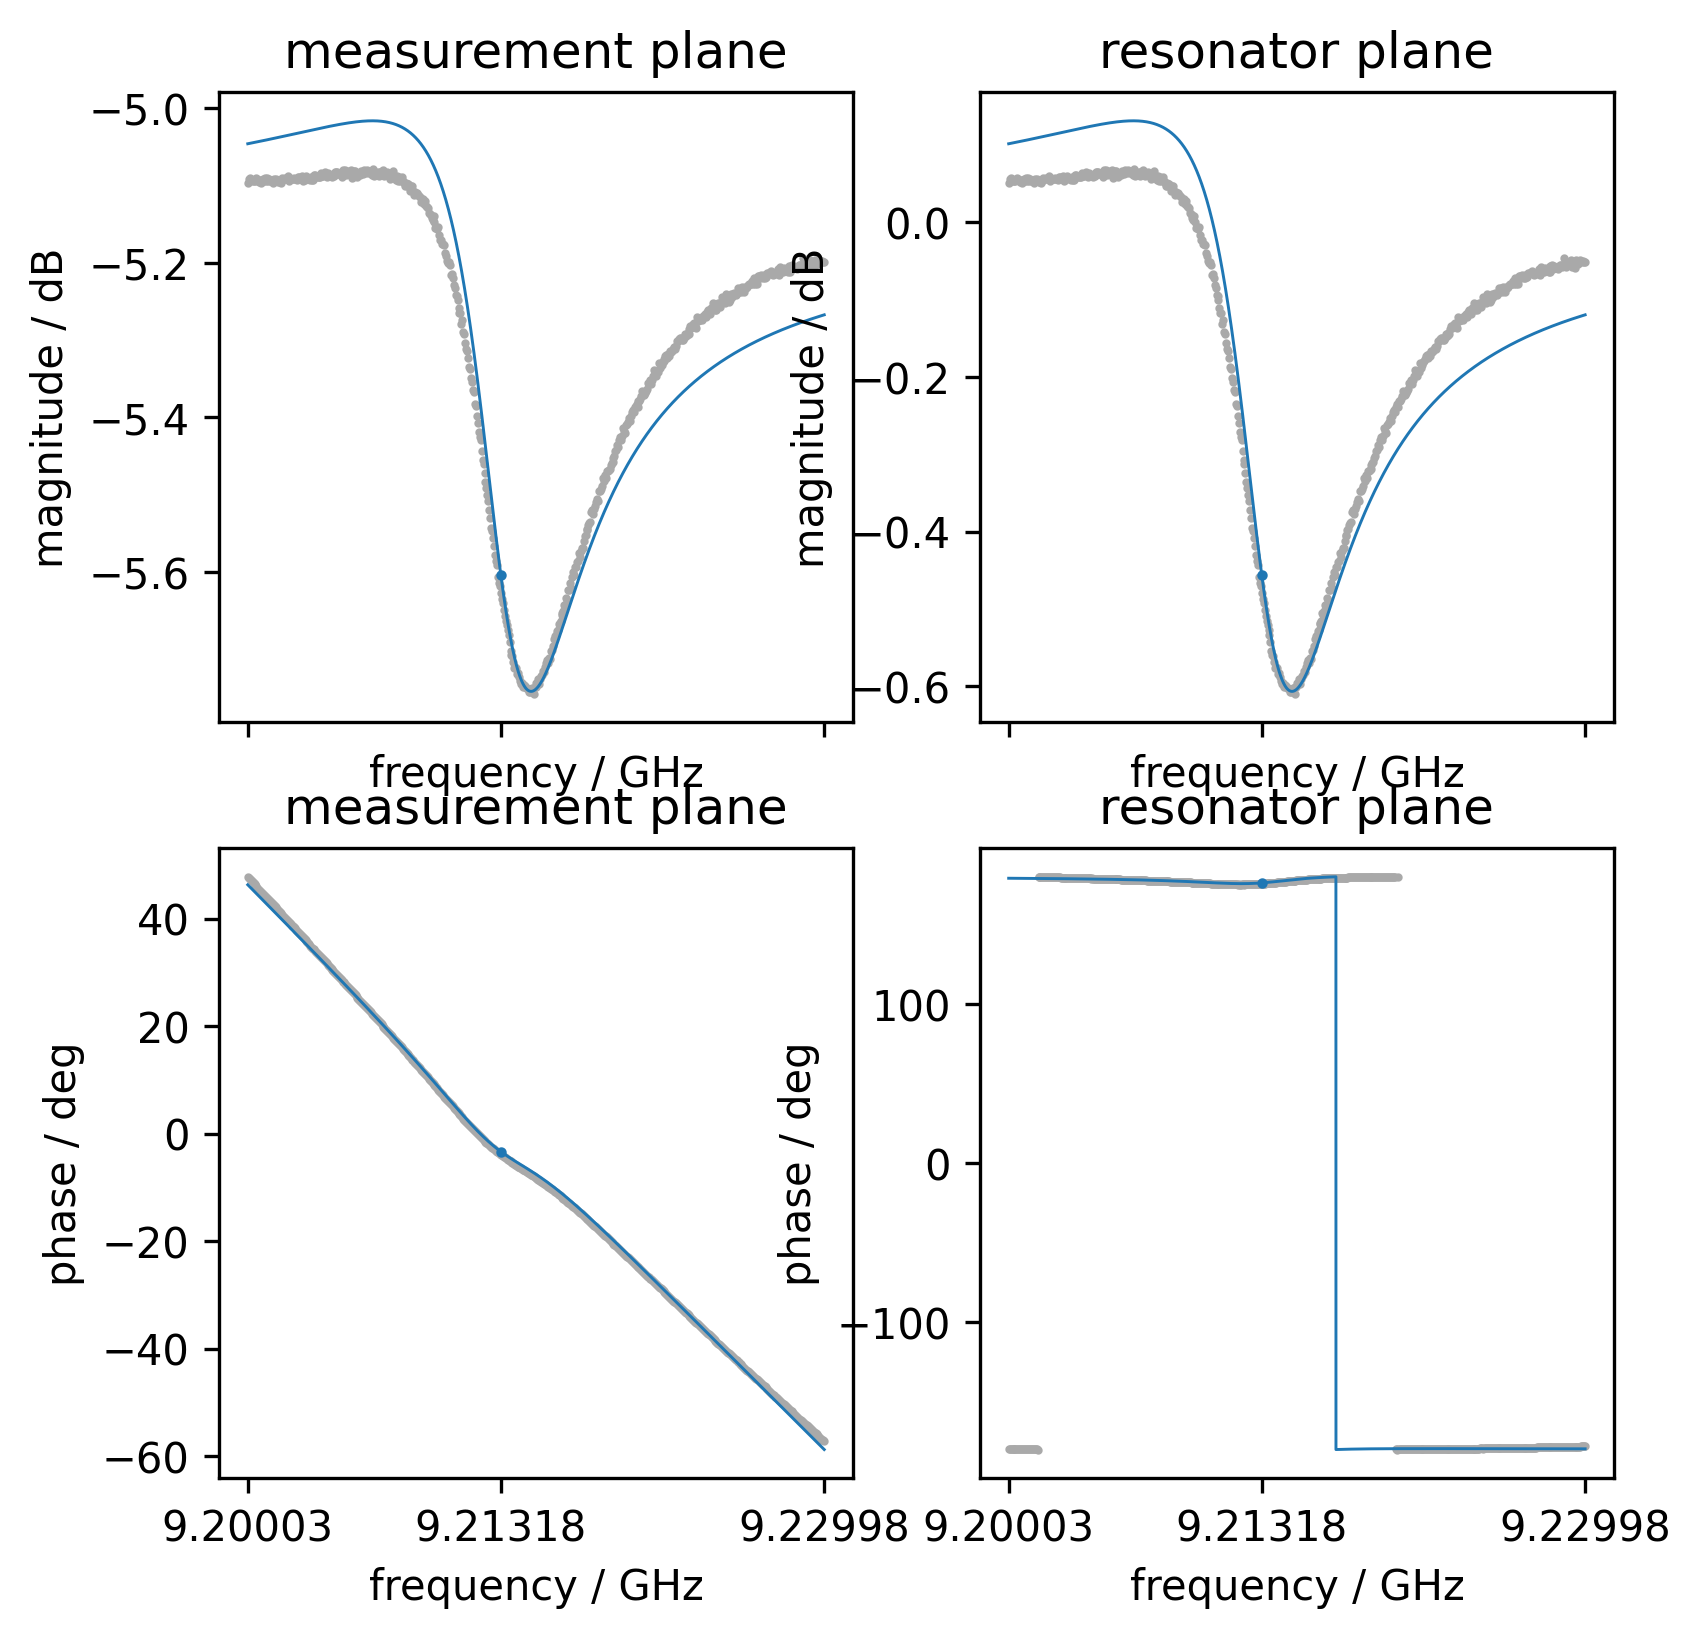

In [7]:
fig, axes = plt.subplots(2, 2, sharex='all', figsize=(6, 6), dpi=300)
ax_raw_mag, ax_norm_mag, ax_raw_phase, ax_norm_phase = axes.flatten()
ax_raw_mag.set_title('measurement plane')
ax_norm_mag.set_title('resonator plane')
ax_raw_phase.set_title('measurement plane')
ax_norm_phase.set_title('resonator plane')
see.magnitude_vs_frequency(resonator=resonator, axes=ax_raw_mag, normalize=False, frequency_scale=1e-9)
see.magnitude_vs_frequency(resonator=resonator, axes=ax_norm_mag, normalize=True, frequency_scale=1e-9)
see.phase_vs_frequency(resonator=resonator, axes=ax_raw_phase, normalize=False, frequency_scale=1e-9)
see.phase_vs_frequency(resonator=resonator, axes=ax_norm_phase, normalize=True, frequency_scale=1e-9);

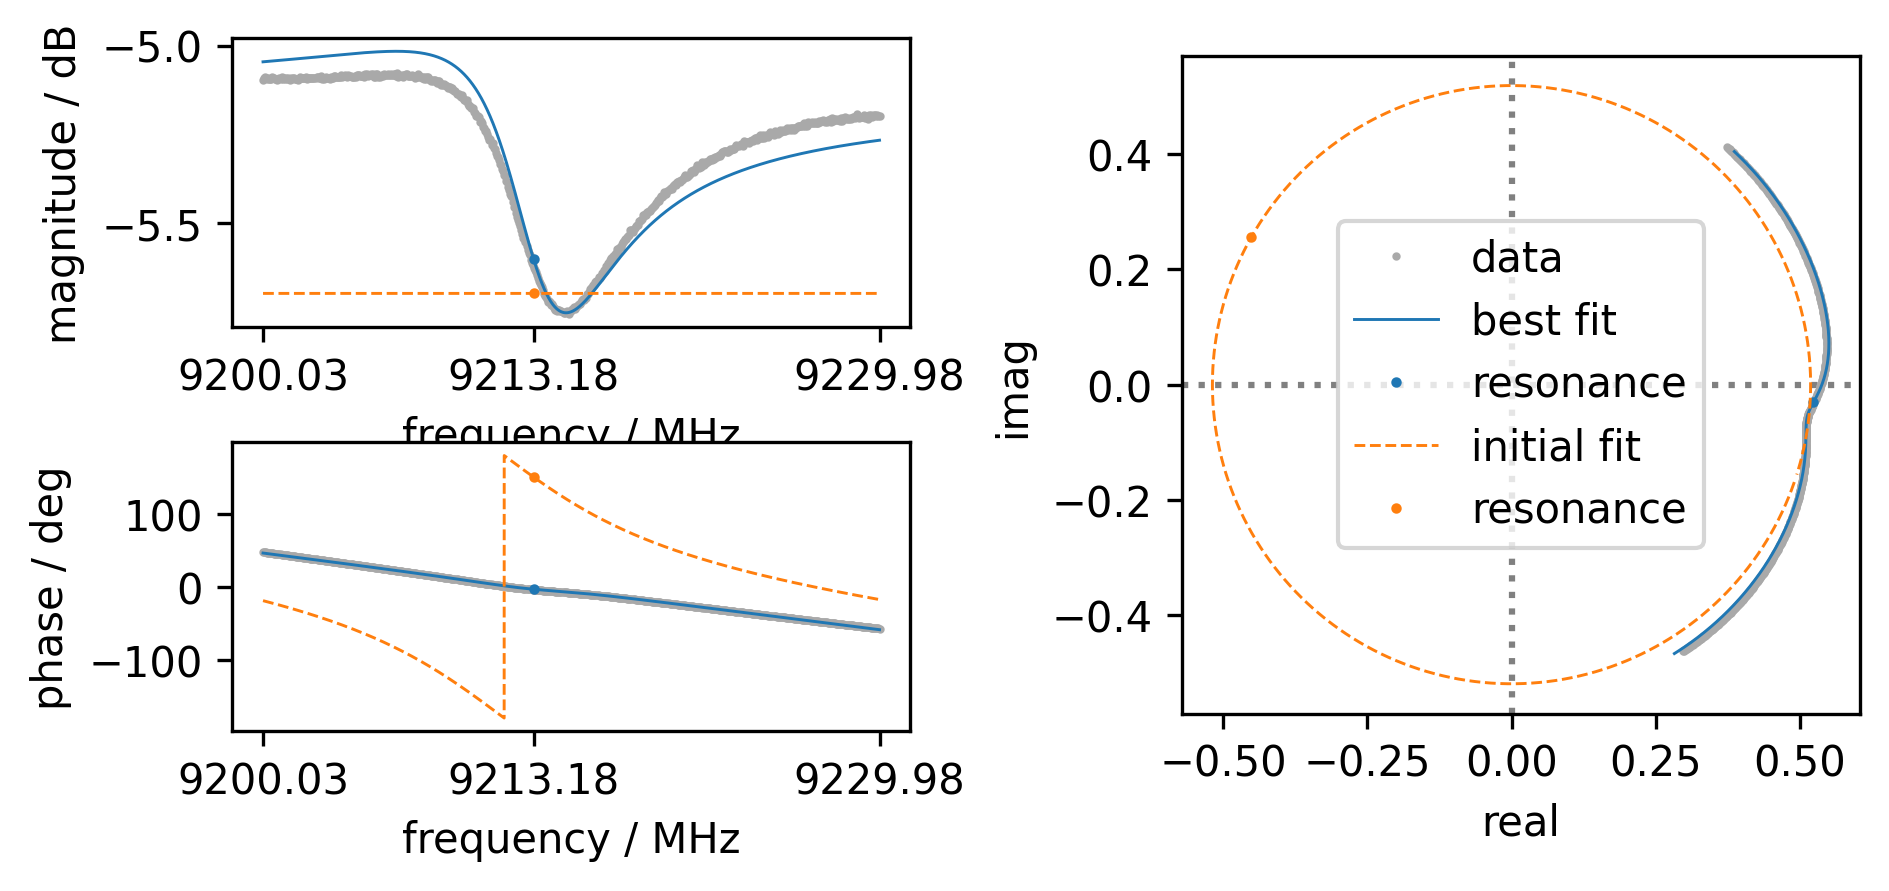

In [8]:
fig, (ax_magnitude, ax_phase, ax_complex) = see.triptych(resonator=resonator, plot_initial=True,
                                                          frequency_scale=1e-6,
                                                          figure_settings={'figsize': (7, 3), 'dpi': 300})
ax_complex.legend();